In [10]:
import scipy.signal as sig
import numpy as np 
import matplotlib.pyplot as plt
import sounddevice as sd
import soundfile as sf
from vocoder_behavioural import vocoder_behavioural
import filter_df2

Generate a voice signal

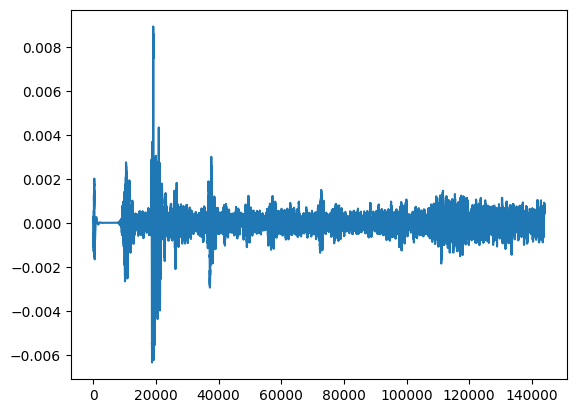

In [4]:
# fs = 44100  # Sample rate given in sounddevice example 
fs = int(48e3)
seconds = 3 # Duration of recording

myrecording = sd.rec(int(seconds * fs), samplerate=fs, channels=1)
sd.wait()  # Wait until recording is finished
plt.plot(myrecording)

Read in test signal 

In [5]:
myrecording, fs = sf.read('hello.wav', dtype='float32')
# plt.plot(myrecording)

In [4]:
# Create a test sinusoid 
f0 = 60
A = 5
phi = 0
n = np.arange(0, 1000)
x = A*np.cos(2*np.pi*(f0/fs)*n+phi)

# Design filter coefficients 

Human voice frequencies: human vocal range 

Total bandwidth: 50Hz-7kHz. Split equally in three to start. 
Procedure is to filter the microphone input (voice) and filter the sawtooth (pitch) with B1. Then mix the results. Repeat the same for B2 and B3. Add all the mixed signals together to produce the output
The sawtooth is produced by 

Fitler order N
N 8-bit registers per bandpass filter (DFII transpose implementation )

Issues: 
* Stability - quantization errors are likely to make bandpass filters unstable 


Options: 
* change bandwidth (some relationship to poles?)
* implement as cascaded biquads 

In [65]:
(band3-fmin)/fs

0.14479166666666668

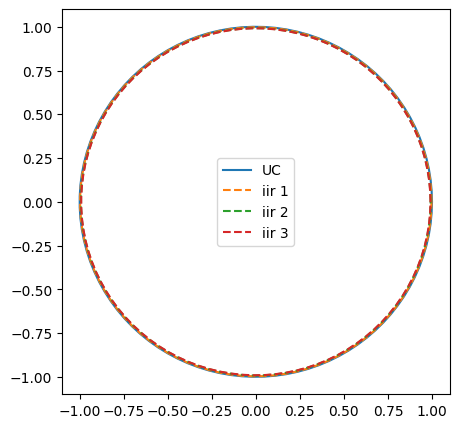

In [5]:
# Choose bandwidth ranges 
fmin = 50
fmax = 1e3
segment = (fmax-fmin)/3 # divide bandwidth equally into three segments 
band1 = fmin + segment
band2 = band1 + segment
band3 = band2 + segment

# Choose filter order 
Norder = 3

# Extract FIR bandpass filter coefficients for each bandwidth
iir_b1, iir_a1 = np.array(sig.iirfilter(N = Norder, Wn=[fmin, band1], btype='bandpass', output='ba', fs=fs)) # cutoff should correspond with -6dB 
iir_b2, iir_a2 = np.array(sig.iirfilter(N = Norder, Wn=[band1, band2], btype='bandpass', output='ba', fs=fs)) 
iir_b3, iir_a3 = np.array(sig.iirfilter(N = Norder, Wn=[band2, band3], btype='bandpass',  output='ba', fs=fs)) 

iir_z1, iir_p1, iir_k1 = sig.iirfilter(N=Norder, Wn=[fmin, band1], btype='bandpass', output='zpk', fs=fs)
iir_z2, iir_p2, iir_k2 = sig.iirfilter(N=Norder, Wn=[band1, band2], btype='bandpass', output='zpk', fs=fs)
iir_z3, iir_p3, iir_k3 = sig.iirfilter(N=Norder, Wn=[band2, band3], btype='bandpass', output='zpk', fs=fs)

r=1
theta = np.linspace(0, np.pi*2, 100)

plt.figure(figsize=(5, 5))
plt.plot(np.cos(theta), np.sin(theta), linestyle='-', label='UC')
plt.plot(max(np.abs(iir_p1))*np.cos(theta), max(np.abs(iir_p1))*np.sin(theta), linestyle='--', label='iir 1')
plt.plot(max(np.abs(iir_p2))*np.cos(theta), max(np.abs(iir_p2))*np.sin(theta), linestyle='--', label='iir 2')
plt.plot(max(np.abs(iir_p3))*np.cos(theta), max(np.abs(iir_p3))*np.sin(theta), linestyle='--', label='iir 3')
plt.legend()

In [13]:
lpfb, lpfa = np.array(sig.iirfilter(N = 1, Wn=100, btype='lowpass', output='ba', fs=fs)) 

In [67]:
w, h = sig.freqz_zpk(iir_z1, iir_p1, iir_k1, fs=fs)
np.max(np.abs(h))  # peak gain in the passband


np.float64(0.9999999999940266)

From CLAUDE: 
Because the poles move further from the unit circle.

For a bandpass filter, the poles sit on the z-plane at roughly the angle corresponding to the centre frequency, and their radius is determined by the bandwidth:

Narrow band → high Q → poles close to unit circle (radius ≈ 0.99)
Wide band → low Q → poles further in (radius ≈ 0.9)
Intuitively: a narrow bandpass needs to "remember" the signal for longer to resolve fine frequency differences — that long memory is reflected in poles close to the unit circle. A wide bandpass forgets faster, so poles sit further in.

The practical consequence is that with wider bands, a quantisation error that shifts a pole by ±0.01 is less likely to push it past 1.0 and cause instability.

Think about what it means to distinguish two closely spaced frequencies.

If you have two sinusoids at 1000 Hz and 1001 Hz, the only way to tell them apart is to observe them for at least 1 second — because that's how long it takes for their phase difference to complete one full cycle. The shorter you observe, the more they look the same.

A narrow bandpass filter is doing exactly this — it's trying to pass 1000 Hz and reject 1001 Hz. To do that it needs a long "observation window", which in the time domain means a slowly decaying impulse response, which means poles close to the unit circle.

A wide bandpass filter doesn't care about distinguishing closely spaced frequencies — it passes everything in a broad range. It can make a decision quickly with a short observation window, so the impulse response decays fast and poles sit further from the unit circle.

This is really just the time-frequency uncertainty principle — the sharper you are in frequency, the longer you need in time.

In [57]:
max(np.abs(iir_p1))

np.float64(0.9990168419107208)

# Use model to check output

In [79]:
out = np.array(vocoder_behavioural(x=myrecording, a1=iir_a1, a2=iir_a2, a3=iir_a3, b1=iir_b1, b2=iir_b2, b3=iir_b3, saw_periods=100))

In [49]:
sd.play(myrecording, fs)

In [80]:
sd.play(10*out, fs)

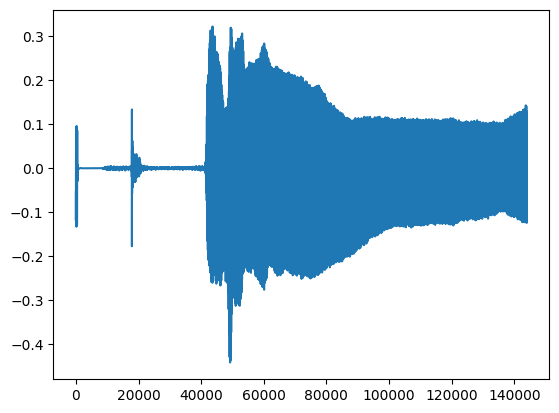

In [61]:
plt.plot(myrecording)

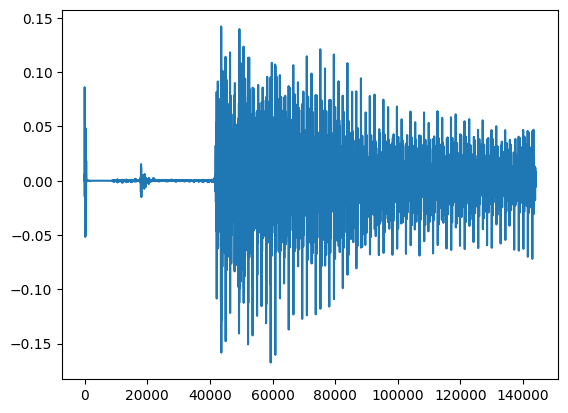

In [19]:
plt.plot(out)

Compare to hardware filter

In [26]:
del hw_int

In [35]:
import importlib
from hw_int import hw_int

# importlib.reload(hw_int)

x = [hw_int(v) for v in [1, 2, 3, 4, 5]] # convert to 8 bit fixed point representation 
xvals = [hw_int(v).val for v in [1, 2, 3, 4, 5]] 

# Testing filter_df2

In [11]:
from filter_df2 import filter_df2
from hw_int import hw_int

x = myrecording

# Calculate filtering action using my function 
mic_iir_1 = filter_df2(iir_b1, iir_a1, x=x)
mic_iir_2 = filter_df2(iir_b2, iir_a2, x=x)
mic_iir_3 = filter_df2(iir_b3, iir_a3, x=x)

# FIltering action
env_1 = filter_df2(lpfb, lpfa, np.abs(mic_iir_1))
env_2 = filter_df2(lpfb, lpfa, np.abs(mic_iir_2))
env_3 = filter_df2(lpfb, lpfa, np.abs(mic_iir_3))


# Generate sawtooth 
saw_periods = 2000
samples = len(x)
n = np.linspace(0, saw_periods*2*np.pi, samples)
pitch = sig.sawtooth(n, 0.2)

# Calculate filtering action using my function 
pitch_iir_1 = filter_df2(iir_b1, iir_a1, x=pitch)
pitch_iir_2 = filter_df2(iir_b2, iir_a2, x=pitch)
pitch_iir_3 = filter_df2(iir_b3, iir_a3, x=pitch)

out_myfilter = np.array([(env_1[i]*pitch_iir_1[i] + env_2[i]*pitch_iir_2[i] + env_3[i]*pitch_iir_3[i]) for i in range(len(mic_iir_1))])



NameError: name 'iir_b1' is not defined

In [6]:
sd.play(myrecording, fs)

In [26]:
sd.play(1e3*out_myfilter, fs)

# Butterworth Claude Suggestion

In [33]:
import numpy as np
from scipy.signal import butter

fs = 48000
n_bands = 4
centers = np.geomspace(300, 5e3, n_bands)

# One octave value per band, or a single scalar applied to all bands
octaves = [2.5, 1.5, 1.5, 1.5, 1, 1, 1, 1]  # wider bandwidth on lowest band

def band_coeffs(fc, fs, octaves=1):
    factor = 2 ** (octaves / 2)
    f_low  = fc / factor
    f_high = min(fc * factor, fs*0.499)
    b, a = butter(1, [f_low, f_high], btype='band', fs=fs)
    return b, a


coeffs = [band_coeffs(fc, fs, octaves=oct) for fc, oct in zip(centers, octaves)]


In [28]:
1/5000

0.0002

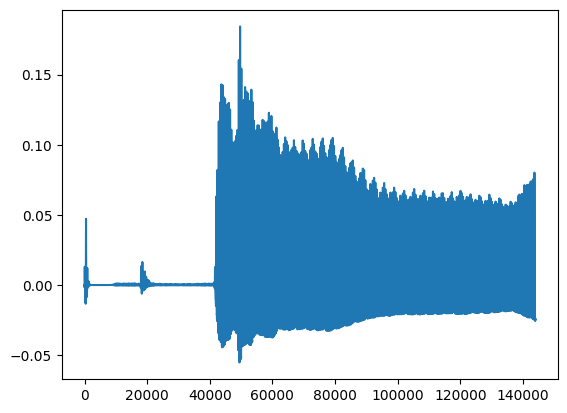

In [34]:
x = myrecording

# Unpack generated coefficients
band_bs = [b for b, a in coeffs]
band_as = [a for b, a in coeffs]

# Filter mic through each band
mic_bands = [filter_df2(b, a, x=x) for b, a in zip(band_bs, band_as)]

lpfb, lpfa = np.array(sig.iirfilter(N = 1, Wn=30, btype='lowpass', output='ba', fs=fs)) 

# Envelope extraction for each band
envs = [filter_df2(lpfb, lpfa, np.abs(band)) for band in mic_bands]

# Generate sawtooth
saw_periods = 360
samples = len(x)
n = np.linspace(0, saw_periods*2*np.pi, samples)
pitch = sig.sawtooth(n, 0.2)

# Filter pitch through each band
pitch_bands = [filter_df2(b, a, x=pitch) for b, a in zip(band_bs, band_as)]

# Combine: sum envelope-modulated pitch bands
out_myfilter = np.sum([env * pitch_band for env, pitch_band in zip(envs, pitch_bands)], axis=0)

plt.plot(out_myfilter)

In [36]:
sd.play(1e1*out_myfilter, fs)

In [31]:
sd.play(myrecording, fs)

# Stability and Size

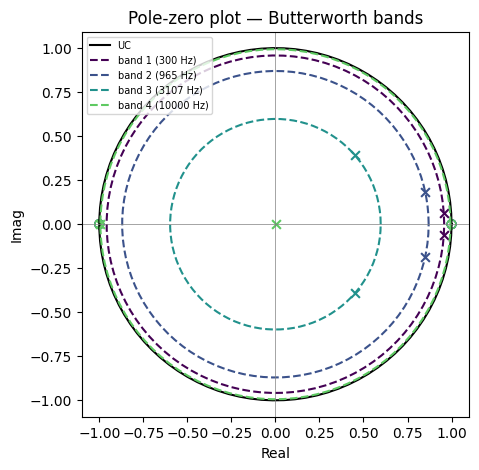

In [165]:
# Extract poles and zeros from Butterworth coeffs and plot on complex plane
zpk_bands = [sig.tf2zpk(b, a) for b, a in coeffs]

theta = np.linspace(0, np.pi*2, 100)

plt.figure(figsize=(5, 5))
plt.plot(np.cos(theta), np.sin(theta), linestyle='-', color='k', label='UC')

for i, (z, p, k) in enumerate(zpk_bands):
    label = f'band {i+1} ({centers[i]:.0f} Hz)'
    color = plt.cm.viridis(i / len(zpk_bands))
    # Pole radius circle (matches existing plot style)
    r = max(np.abs(p))
    plt.plot(r*np.cos(theta), r*np.sin(theta), linestyle='--', color=color, label=label)
    # Actual poles and zeros
    plt.scatter(p.real, p.imag, marker='x', color=color, s=40)
    plt.scatter(z.real, z.imag, marker='o', facecolors='none', edgecolors=color, s=40)

plt.axhline(0, color='grey', linewidth=0.5)
plt.axvline(0, color='grey', linewidth=0.5)
plt.legend(fontsize=7, loc='upper left')
plt.title('Pole-zero plot — Butterworth bands')
plt.xlabel('Real')
plt.ylabel('Imag')
plt.axis('equal')
plt.show()

In [1]:
from scipy.signal import tf2zpk

# Quantize coefficients to N bits then recheck poles
bits = 8
scale = 2**(bits-1)

for i, (b, a) in enumerate(coeffs):
    b_q = np.round(b * scale) / scale    # quantize
    a_q = np.round(a * scale) / scale
    z, p, k = tf2zpk(b_q, a_q)
    max_pole = max(np.abs(p))
    stable = "OK" if max_pole < 1.0 else "UNSTABLE"
    print(f"Band {i+1} ({centers[i]:.0f} Hz): max|p| = {max_pole:.6f}  [{stable}]")


NameError: name 'coeffs' is not defined

In [88]:
for i, (z, p, k) in enumerate(zpk_bands):
    print(f"Band {i+1} ({centers[i]:.0f} Hz): poles = {p}, max|p| = {max(np.abs(p)):.6f}")


Band 1 (300 Hz): poles = [0.97791211+0.05363437j 0.97791211-0.05363437j 0.99038867+0.02436118j
 0.99038867-0.02436118j], max|p| = 0.990688
Band 2 (533 Hz): poles = [0.95906296+0.0937753j  0.95906296-0.0937753j  0.98255383+0.04299643j
 0.98255383-0.04299643j], max|p| = 0.983494
Band 3 (949 Hz): poles = [0.92223115+0.16165219j 0.92223115-0.16165219j 0.96786396+0.07541724j
 0.96786396-0.07541724j], max|p| = 0.970798
Band 4 (1687 Hz): poles = [0.93939498+0.13072076j 0.93939498-0.13072076j 0.84742191+0.27114634j
 0.84742191-0.27114634j], max|p| = 0.948447
Band 5 (3000 Hz): poles = [0.88167351+0.22114119j 0.88167351-0.22114119j 0.69069024+0.43012173j
 0.69069024-0.43012173j], max|p| = 0.908984


In [83]:
for i, (z, p, k) in enumerate(zpk_bands):
    print(f"Band {i+1} ({centers[i]:.0f} Hz): poles = {p}, max|p| = {max(np.abs(p)):.6f}")


Band 1 (100 Hz): poles = [0.99291337+0.01813357j 0.99291337-0.01813357j 0.99685345+0.00817198j
 0.99685345-0.00817198j], max|p| = 0.996887
Band 2 (376 Hz): poles = [0.97192624+0.06686558j 0.97192624-0.06686558j 0.9878703 +0.03046332j
 0.9878703 -0.03046332j], max|p| = 0.988340
Band 3 (1414 Hz): poles = [0.87634759+0.23236923j 0.87634759-0.23236923j 0.95025893+0.11064485j
 0.95025893-0.11064485j], max|p| = 0.956679
Band 4 (5318 Hz): poles = [0.75991331+0.35284124j 0.75991331-0.35284124j 0.36549826+0.59980842j
 0.36549826-0.59980842j], max|p| = 0.837834
Band 5 (20000 Hz): poles = [-0.99555719+0.00445069j -0.99555719-0.00445069j  0.00647568+0.4160256j
  0.00647568-0.4160256j ], max|p| = 0.995567


Both extremes are problematic but for different reasons:

Low frequencies (100 Hz) — slow decay problem

At 48 kHz sample rate, 100 Hz is only 0.002% of the Nyquist frequency. The filter needs to "remember" the signal across thousands of samples to operate at that timescale — long memory means poles very close to 1.0. It's the time-frequency uncertainty principle: resolving low frequencies requires a long observation window.

High frequencies near Nyquist (20 kHz) — mirror image problem

20 kHz is 0.002% below Nyquist (24 kHz). The filter now needs to distinguish 20 kHz from 24 kHz, which is the same problem in reverse — a narrow band near Nyquist requires poles close to -1.0 (the Nyquist point on the unit circle), which you can see in your results:


Band 5: poles = [-0.9956 + 0.0045j, ...]
Those poles are near -1, not +1 — it's the high-frequency mirror of the low-frequency problem.

The middle bands are fine because they sit comfortably away from both +1 and -1, so the filter doesn't need extreme precision to operate correctly.

Geometrically: the unit circle has two "danger zones" for stability — near +1 (DC/low freq) and near -1 (Nyquist/high freq). Your bands at the extremes sit right next to those zones.



# Tests

* reduce frequency from 100 to 20e3 to 300 to 3e3
* change from 1 octave bandwidth to 1.5 octave bandwidth to reduce q factor


Band 1 (300 Hz): poles = [0.97791211+0.05363437j 0.97791211-0.05363437j 0.99038867+0.02436118j
 0.99038867-0.02436118j], max|p| = 0.990688
Band 2 (533 Hz): poles = [0.95906296+0.0937753j  0.95906296-0.0937753j  0.98255383+0.04299643j
 0.98255383-0.04299643j], max|p| = 0.983494
Band 3 (949 Hz): poles = [0.92223115+0.16165219j 0.92223115-0.16165219j 0.96786396+0.07541724j
 0.96786396-0.07541724j], max|p| = 0.970798
Band 4 (1687 Hz): poles = [0.93939498+0.13072076j 0.93939498-0.13072076j 0.84742191+0.27114634j
 0.84742191-0.27114634j], max|p| = 0.948447
Band 5 (3000 Hz): poles = [0.88167351+0.22114119j 0.88167351-0.22114119j 0.69069024+0.43012173j
 0.69069024-0.43012173j], max|p| = 0.908984

 * Then increasing octaves to 2 to see if the stability changes
 * Reduce number of bands
 * halve sample frequency 
 * make bandwidth of lowest centre frequency wider 
 * Drop order of butterworth 

# Claude Info

For speech intelligibility the research is pretty clear:

Minimum viable: 300 Hz – 3400 Hz

This is literally the POTS telephone band (G.711 standard) — it's been the baseline for intelligible speech for 100 years. You can understand everything someone says in this range.

Better: 300 Hz – 4000 Hz

Adds consonant clarity (s, f, th sounds live in 3–4 kHz). Noticeable improvement in naturalness.

For a vocoder specifically:

The carrier (sawtooth) provides the pitch/harmonics, so you don't need the fundamental frequency in the band — you just need the formants (resonances that shape vowels and consonants):

F1 (first formant): 300–1000 Hz — vowel openness
F2 (second formant): 800–2500 Hz — vowel colour
F3 (third formant): 2000–3500 Hz — consonant character
So 300 Hz – 3500 Hz captures all three formants and gives a recognisable vocoder effect.

Practical recommendation for your hardware:


centers = np.geomspace(300, 3500, n_bands)
This keeps all poles well away from both +1 and -1, and 5–8 bands across this range will sound good. Going below 300 Hz adds bass rumble but hurts stability; going above 4 kHz adds presence but the bands near Nyquist become unstable at 8-bit.



It depends on your coefficient word length. The quantization step size is:


step = 2^(1-N)    for N-bit signed fixed point (Q format)
Word length	Step size	Minimum safe margin
8-bit	0.0078	~0.01 (2× step)
16-bit	0.00003	~0.0001
24-bit	0.0000001	negligible
For 8-bit you want margin > ~0.01 — roughly 2× the step size to give yourself some headroom. Your Band 1 at 0.003 is below the step size itself, which is why it fails.

You can compute it directly for your design:


bits = 8
step = 2 ** (1 - bits)
print(f"Step size: {step:.6f}")

for i, (z, p, k) in enumerate(zpk_bands):
    margin = 1 - max(np.abs(p))
    safe = "OK" if margin > 2*step else "UNSTABLE"
    print(f"Band {i+1} ({centers[i]:.0f} Hz): margin = {margin:.6f}  [{safe}]")
This tells you exactly which bands survive 8-bit quantization and which don't, and you can swap bits = 16 to see how much 16-bit buys you.

where does that rule come from
It's a rule of thumb, not a theorem. The real answer is more nuanced:

What actually determines stability under quantization:

When you quantize a coefficient, you shift the pole by some amount in the z-plane. Whether the filter stays stable depends on:

How sensitive the pole location is to that coefficient — this is called pole sensitivity, and it varies by filter structure and frequency. Direct Form II has poor sensitivity; SOS is better.

The direction the pole moves — a shift that moves the pole tangentially (along the unit circle) is harmless; a shift that moves it radially outward is fatal.

All coefficients interact — quantizing b0, b1, b2, a1, a2 simultaneously shifts poles in different directions that can partially cancel or compound.

The proper way to check:


from scipy.signal import tf2zpk

# Quantize coefficients to N bits then recheck poles
bits = 8
scale = 2**(bits-1)

for i, (b, a) in enumerate(coeffs):
    b_q = np.round(b * scale) / scale    # quantize
    a_q = np.round(a * scale) / scale
    z, p, k = tf2zpk(b_q, a_q)
    max_pole = max(np.abs(p))
    stable = "OK" if max_pole < 1.0 else "UNSTABLE"
    print(f"Band {i+1} ({centers[i]:.0f} Hz): max|p| = {max_pole:.6f}  [{stable}]")
This actually quantizes the coefficients and checks the resulting poles directly — no rule of thumb needed. If max|p| >= 1.0 after quantization, the filter is unstable.



In [ ]:
fig, (ax_mag, ax_phase) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

for i, (b, a) in enumerate(coeffs):
    w, h = sig.freqz(b, a, worN=4096, fs=fs)
    color = plt.cm.viridis(i / len(coeffs))
    label = f'band {i+1} ({centers[i]:.0f} Hz)'
    ax_mag.plot(w, 20 * np.log10(np.abs(h) + 1e-12), color=color, label=label)
    ax_phase.plot(w, np.unwrap(np.angle(h)) * 180 / np.pi, color=color, label=label)

ax_mag.set_ylabel('Magnitude (dB)')
ax_mag.set_ylim(-60, 5)
ax_mag.legend(fontsize=8)
ax_mag.grid(True, alpha=0.3)
ax_mag.set_title('Filter bank frequency response')

ax_phase.set_ylabel('Phase (degrees)')
ax_phase.set_xlabel('Frequency (Hz)')
ax_phase.legend(fontsize=8)
ax_phase.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
